<a href="https://colab.research.google.com/github/OlesiaLelet/Sales-analysis/blob/main/sales_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade google-cloud-bigquery
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
auth.authenticate_user()
import matplotlib.pyplot as plt
import seaborn as sns
client = bigquery.Client(project="data-analytics-mate")

query = """

select s.date,
       s.ga_session_id,
       sp.continent,
       sp.country,
       sp.device,
       sp.browser,
       sp.mobile_model_name,
       sp.operating_system,
       sp.language,
       sp.medium,
       sp.channel,
       acs.account_id,
       ac.is_verified,
       ac.is_unsubscribed,
       p.category,
       p.name,
       p.price,
       p.short_description

FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
ON s.ga_session_id = sp.ga_session_id

LEFT JOIN `data-analytics-mate.DA.order` o
ON s.ga_session_id = o.ga_session_id

LEFT JOIN `data-analytics-mate.DA.product` p
ON o.item_id = p.item_id

LEFT JOIN `data-analytics-mate.DA.account_session` acs
ON s.ga_session_id = acs.ga_session_id

LEFT JOIN `data-analytics-mate.DA.account` ac
ON acs.account_id = ac.id

"""
query_job = client.query(query)  # Виконання SQL-запиту
results = query_job.result()  # Очікування завершення запиту

df = results.to_dataframe(create_bqstorage_client=False)

# Виведення результату
df.head(10)






,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,medium,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
5,2020-11-01,967742695,Americas,United States,desktop,Safari,Safari,Web,en-us,(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
6,2020-11-01,1115082532,Europe,Germany,desktop,Chrome,Safari,Macintosh,None,referral,Paid Search,<NA>,<NA>,<NA>,Cabinets & cupboards,GALANT,2270.0,"Storage combination with drawers, 80x160 cm"
7,2020-11-01,6586349543,Americas,(not set),desktop,Chrome,Safari,Web,en-us,referral,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
8,2020-11-01,5041302343,Americas,Ecuador,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
9,2020-11-01,1129172264,Americas,United States,mobile,Chrome,<Other>,Android,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


## Data cleaning.
У стовпці language пропущених значень 32.7%, що може бути через помилку визначення мови.Оскільки це категоріальні дані, то можемо їх заповнити "unknown". У стовпцях account_id, is_verified, is_unsubscribed відсоток пропущених значень становить  91.707913%, що свідчить, що зареєстрованих аккаунтів є дуже мало, більшість користувачів - незареєстровані. Стопці category, name, price, short_description взяті із таблиці products мають відсоток 90.41% пропущених значень, що може свідчити, що лише невелика кількість сесій призвела до покупок. Категоріальні стовпці заповнимо "unknown", а стовпець price залишимо таким як є аби не спотворити обчислення.

## Опис датасету
Загальна кількість колонок - 18.  

З них 5 - числового типу ( ga_session_id, account_id, is_verified, is_unsubscribed, price).  

Категоріальні: 12 (continent, country, device, browser, mobile_model_name,
operating_system, language, medium, channel, category, name, short_description).

Колонки типу дата і час: 1 (date).

Кількість унікальних сесій: 33538.

Період: з  2020-11-01 по 2021-01-27.

Дуплікатів немає.







In [ ]:
df.info()

# Робота з пропущеними значеннями
missed_values = df.isna().sum()
percent_of_missed_values = (df.isna().sum() / df.shape[0]) * 100
df["language"] = df['language'].fillna("unknown")
print(f"percent of missed values:\n {percent_of_missed_values}")

df["category"] = df['category'].fillna("unknown")
df["name"] = df['name'].fillna("unknown")
df["short_description"] = df['short_description'].fillna("unknown")

# загальна кількість колонок
total_columns = df.shape[1]
print(f"Total columns count: {total_columns}")

# колонки категоріального типу
categorical = df.dtypes == object
print(f"Number of cathegorical columns: {categorical.sum()}")
print(categorical)

# кількість унікальних сесій
unique_sessions = df["ga_session_id"].unique().shape[0]
print(unique_sessions)

# період часу
last_date = df["date"].max()
first_date = df["date"].min()
print(first_date, last_date)

# наявність дублікатів
duplicated_rows = df.duplicated()
print(f"duplicated_rows:\n{duplicated_rows.sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           349545 non-null  object 
 9   medium             349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           349545 non-null  object 
 15  name               349545 non-null  object 
 16  pr

            country  account_id
104   United States       12384
43            India        2687
18           Canada        2067
103  United Kingdom         859
33           France         553
92            Spain         536
96           Taiwan         500
20            China         490
35          Germany         490
48            Italy         386
71.69797817140812
16.94399713723385
Average check of subscribed clients: 92.66682033606205.
Average check of unsubscribed clients: 91.17668426610348


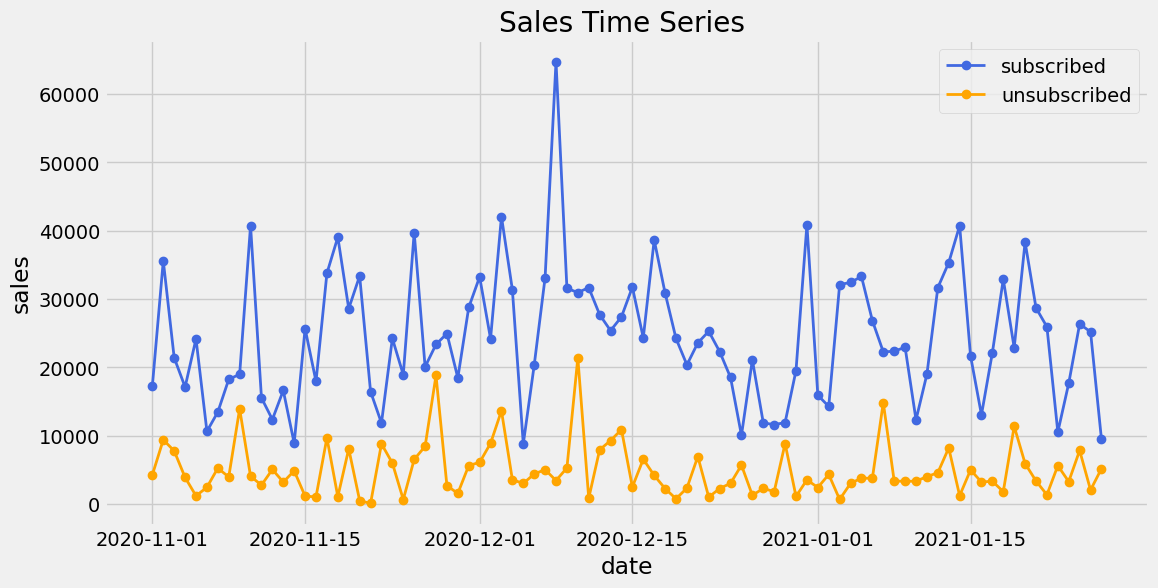

channel
Direct            23.442345
Organic Search    35.760189
Paid Search       26.620546
Social Search      7.919827
Undefined          6.257093
Name: price, dtype: float64
Sales by devices:
      device mobile_model_name  %_of_total
0   desktop           <Other>    1.644093
1   desktop            Chrome   27.835602
2   desktop        ChromeBook    5.725241
3   desktop              Edge    2.179667
4   desktop           Firefox    1.316998
5   desktop            Safari   20.300643
6    mobile           <Other>   17.937951
7    mobile              Edge    0.001079
8    mobile           Pixel 3    0.341390
9    mobile        Pixel 4 XL    0.369976
10   mobile            Safari    0.001861
11   mobile            iPhone   20.082667
12   tablet           <Other>    0.858922
13   tablet              iPad    1.403910
      device        date     price
0    desktop  2020-11-01  144445.0
1    desktop  2020-11-02  206727.3
2    desktop  2020-11-03  304473.8
3    desktop  2020-11-04  212227.7


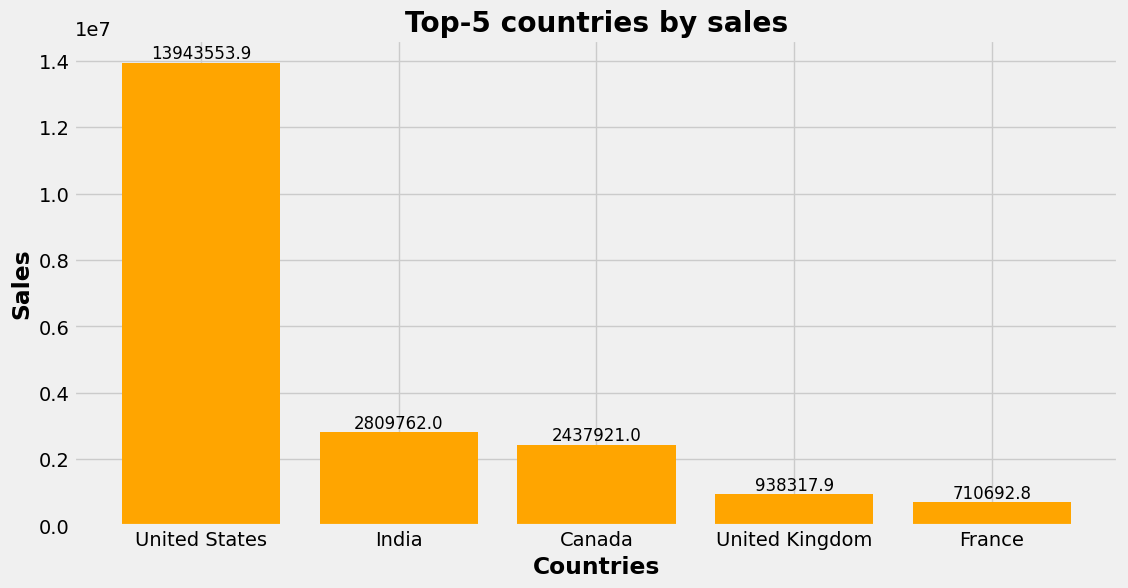

Top-3 continents :
   continent       sales
2  Americas  17665280.0
3      Asia   7601298.3
4    Europe   5934624.2


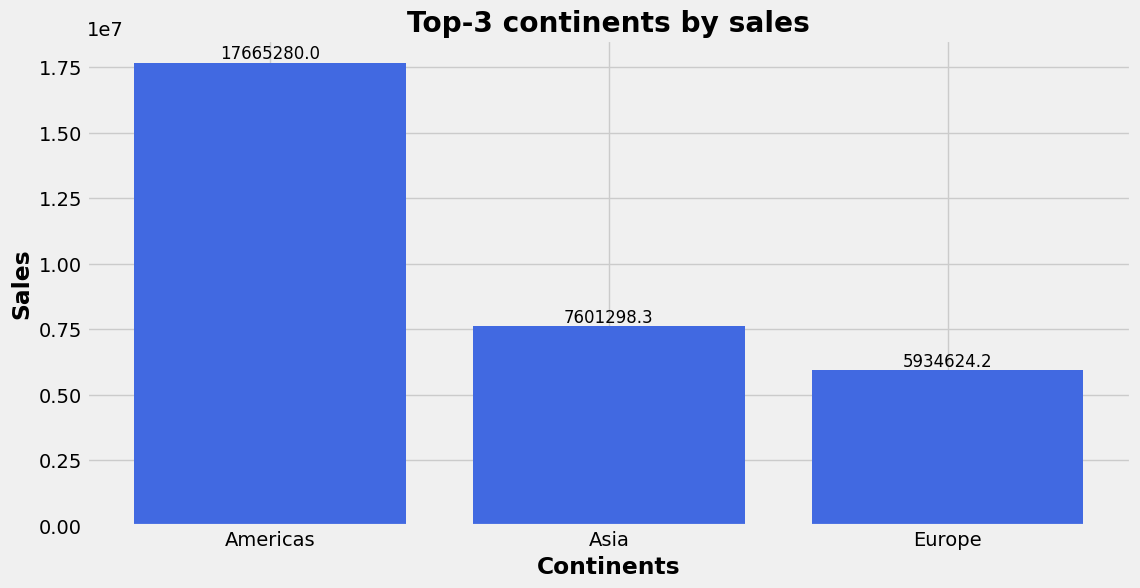

                           category  rank_total  rank_country
0                     Bar furniture           9             9
1                              Beds           3             3
2        Bookcases & shelving units           4             4
3              Cabinets & cupboards           5             5
4                            Chairs           2             2
5  Chests of drawers & drawer units           8             8
6              Children's furniture          10            10
7                 Outdoor furniture           6             6
8                 Sofas & armchairs           1             1
9                    Tables & desks           7             7


In [ ]:
# в яких країнах найбільше зареєстрованих користувачів?
top_5_countries_with_registered_clients = df[df["account_id"].notnull()].groupby("country")["account_id"].count().reset_index().sort_values(by="account_id", ascending = False).head(10)
print(top_5_countries_with_registered_clients)

# який відсоток зареєстрованих користувачів підтвердив свою електронну адресу?
is_verified_percent = df[df["account_id"].notnull() & df["is_verified"] == 1].shape[0] / df[df["account_id"].notnull()].shape[0] * 100
print(is_verified_percent)

# який відсоток зареєстрованих користувачів відписався від розсилки?
is_unsubscribed_percent  = df[df["account_id"].notnull() & df["is_unsubscribed"] == 1].shape[0] / df[df["account_id"].notnull()].shape[0] * 100
print(is_unsubscribed_percent)

# чи відрізняється поведінка (у плані продажів) тих, хто відписався від розсилки та тих, хто досі підписаний?
sales_of_unsubscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 1]["price"].sum()
sales_of_subscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 0]["price"].sum()
avg_check_of_unsubscribed = sales_of_unsubscribed / df[df["account_id"].notnull() & df["is_unsubscribed"] == 1].shape[0]
avg_check_of_subscribed = sales_of_subscribed / df[df["account_id"].notnull() & df["is_unsubscribed"] == 0].shape[0]
print(f"Average check of subscribed clients: {avg_check_of_subscribed}.\nAverage check of unsubscribed clients: {avg_check_of_unsubscribed}")


repeated_purchases_of_subscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 0].groupby("account_id")["ga_session_id"].nunique().reset_index(name = "session_id_cnt").sort_values(by="session_id_cnt", ascending = False)
repeated_purchases_of_subscribed_more = repeated_purchases_of_subscribed[repeated_purchases_of_subscribed["session_id_cnt"] >=2]
repeated_purchases_of_unsubscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 1].groupby("account_id")["ga_session_id"].nunique().reset_index(name = "session_id_cnt").sort_values(by="session_id_cnt", ascending = False)

# Динаміка продажів зареєстрованих і незареєстрованих користувачів
dynamic_subscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 0].groupby("date")["price"].sum().reset_index()
dynamic_unsubscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 1].groupby("date")["price"].sum().reset_index()

plt.figure(figsize=(12, 6))

plt.plot(dynamic_subscribed["date"], dynamic_subscribed["price"], label="subscribed", linewidth= 2, marker= "o", color = "royalblue")
plt.plot(dynamic_unsubscribed["date"], dynamic_unsubscribed["price"], label="unsubscribed", linewidth= 2, marker= "o", color= "orange")

plt.xlabel("date")
plt.ylabel("sales")
plt.title("Sales Time Series ")
plt.legend()
plt.grid(True)
plt.show()

# продажі за джерелами трафіку (у % від загальних продажів)
total_sales = df["price"].sum()
groupby_channels = df.groupby("channel")["price"].sum() / total_sales * 100
print(groupby_channels)

# продажі у розрізі типів та моделей девайсів (у % від загальних продажів)
groupby_devices = (df.groupby(by = ["device", "mobile_model_name"])["price"].sum() / total_sales * 100).reset_index(name="%_of_total")
print(f"Sales by devices:\n {groupby_devices}")

# Динаміка продажів за пристроями
grouped_by_devices = df.groupby(by=["device", "date"])["price"].sum().reset_index()
print(grouped_by_devices)

# на яких континентах (топ-3) та в яких країнах (топ-5) наша компанія має найбільші продажі? найбільшу кількість замовлень?


top_5_countries = df.groupby("country")["price"].sum().reset_index(name = "sales").sort_values(by="sales", ascending = False).head(5)
print(f"Top-5 countries:\n {top_5_countries}")


plt.figure(figsize=(12, 6))
plt.style.use("seaborn-v0_8-pastel")
countries_bars = plt.bar(top_5_countries["country"], top_5_countries["sales"], color="orange")
for bar in countries_bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 40,
        f"{bar.get_height()}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=12,
    )

plt.xlabel("Countries", fontweight="semibold")
plt.ylabel("Sales", fontweight="semibold")
plt.title("Top-5 countries by sales", fontweight="semibold")
plt.grid(True)
plt.show()

top_3_continents = df.groupby("continent")["price"].sum().reset_index(name = "sales").sort_values(by="sales", ascending = False).head(3)
print(f"Top-3 continents :\n {top_3_continents}")

plt.figure(figsize=(12, 6))

continents_bars = plt.bar(top_3_continents["continent"], top_3_continents['sales'], color="royalblue")
for bar in continents_bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 40,
        f"{bar.get_height()}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=12,
    )

plt.xlabel("Continents", fontweight="semibold")
plt.ylabel("Sales", fontweight="semibold")
plt.title("Top-3 continents by sales", fontweight="semibold")
plt.grid(True)
plt.show()

# топ-10 категорій товарів у країні з найбільшими продажами, чи відрізняється ситуація від загальної?
top_1_country = top_5_countries.iloc[0]["country"]
top_10_categories_in_top_country = df[df["country"] == top_1_country].groupby("category")["price"].sum().reset_index(name="sales").sort_values(by="sales", ascending= False).head(10)
#print(top_10_categories_in_top_country)

top_10_categories_in_total = df.groupby("category")["price"].sum().reset_index(name="sales").sort_values(by="sales", ascending= False).head(10)
#print(f"\n\n {top_10_categories_in_total}")

top_10_categories_in_top_country["rank_country"] = range(1,11)
top_10_categories_in_total["rank_total"] = range(1,11)

comparison = pd.merge(top_10_categories_in_total[["category", "rank_total"]], top_10_categories_in_top_country[["category", "rank_country"]], on="category", how="outer")

print(comparison)


## Аналіз динаміки продажів.
Графік часової динаміки продажів показав високу волатильність та наявність короткострокових циклічних коливань. Виявлено ознаки тижневої сезонності: піки та спади продажів повторюються приблизно кожні 7 днів. Також були виявлені аномальні сплески продажів у період святкового (перша половина грудня та перший тиждень січня) сезону, що може свідчити про вплив маркетингових кампаній та сезонного попиту.
### У розрізі континентів.
Найбільш прибутковою є Америка, але продажі є нестабільними. Спостерігається тижнева сезонність, що може бути пов'язана із маркетинговими кампаніями або зростанням попиту у певні дні тижня. Найбільші продажі ( приблизно 360000$ )  
  
виявлені у першій половині грудні та першому тижні січня.Такі піки повторються і на інших континтах : Азії та Європи (найбільше значення продажів - 150000$), що може свідчити про наявність святкових маркетингових кампаній чи сезонного попиту. Азія демонструє більш стабільну динаміку з помірними коливаннями, тоді як Європа має найнижчий рівень продажів та слабше виражені сезонні ефекти.

### У розрізі каналів трафіку.

- **Organic Search** є основним джерелом продажів. Щоденні продажі переважно становлять 90-180 тис. дол., а максимальне значення досягає приблизно 270 тис. дол..
- **Paid Search** займає друге місце за обсягом продажів. Більшість значень знаходиться в межах 80-150 тис. дол., а пік сягає близько 200 тис. дол.
- **Direct** демонструє стабільні результати з продажами переважно на рівні 60-120 тис. дол. та максимальним значенням близько 145 тис. дол.
- **Social Search** генерує найменший обсяг продажів — зазвичай 15-40 тис. дол., з окремими піками до 60 тис. дол.

## Сезонність

- Найвищі продажі спостерігаються на початку та в середині грудня.
- У цей період:
  - Organic Search досягає приблизно **270 тис. $**;

  - Paid Search — близько **200 тис. $**;  
  
  - Direct — близько **145 тис. $**;

  - Social Search — близько **60 тис. $**.
- Після новорічних свят продажі знижуються в усіх каналах та повертаються до середніх значень.

## Особливості динаміки

- Organic Search та Paid Search мають схожий характер змін і часто демонструють піки в одні й ті самі дні.
- Direct також зростає під час загальних сплесків попиту, але менш різко.
- Social Search повторює загальний тренд, проте його внесок у загальний обсяг продажів залишається незначним.

## Рекомендації

- Продовжувати інвестувати в SEO, оскільки Organic Search забезпечує найбільшу виручку.
- Проаналізувати ефективність Paid Search, адже канал генерує значний обсяг продажів і має потенціал для масштабування.
- Дослідити причини низької частки Social Search та оцінити доцільність подальших інвестицій у цей канал.
- Окремо проаналізувати грудневий період, оскільки саме тоді спостерігаються максимальні продажі в усіх каналах.

/tmp/ipykernel_17026/4001713696.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


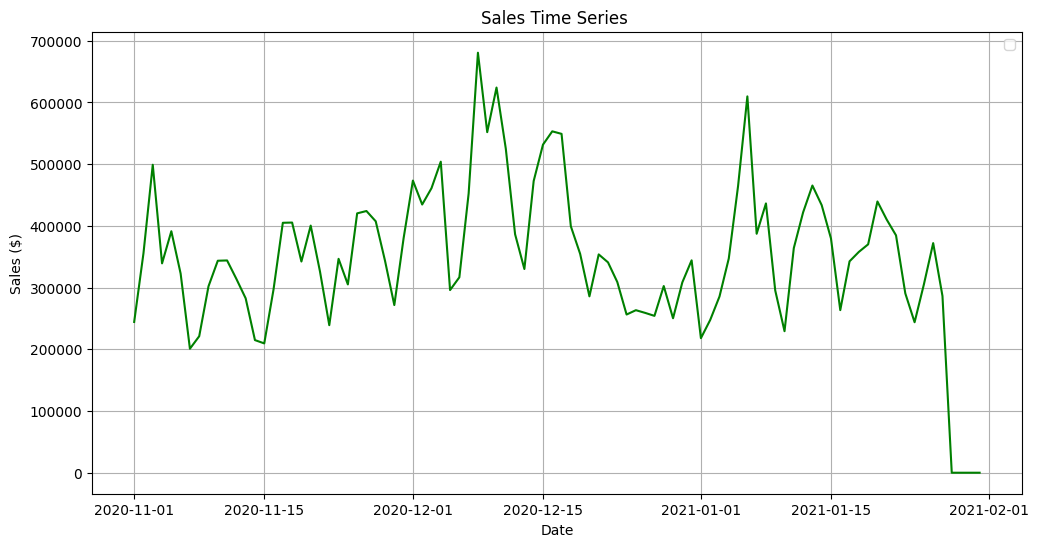

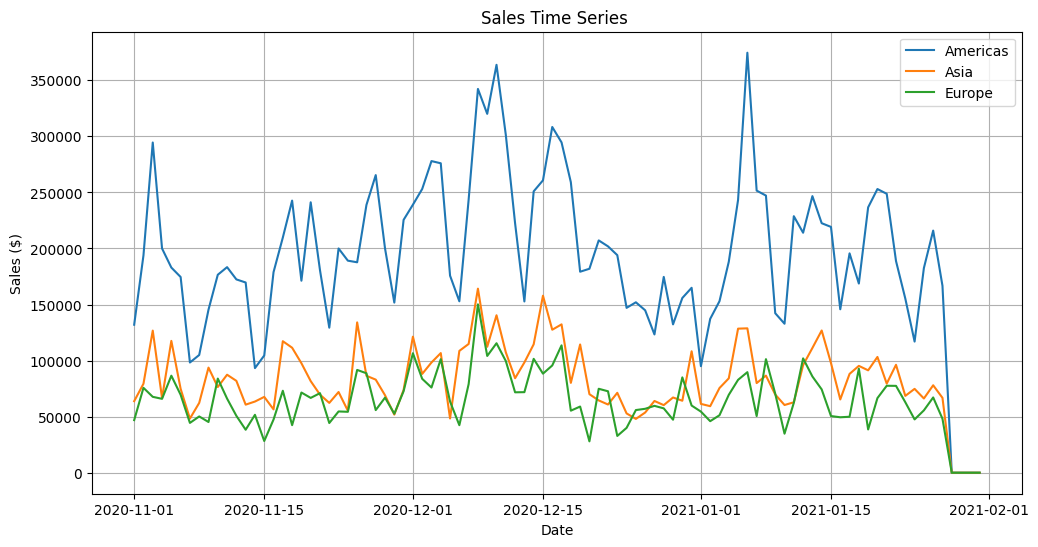

['Direct' 'Organic Search' 'Paid Search' 'Social Search']


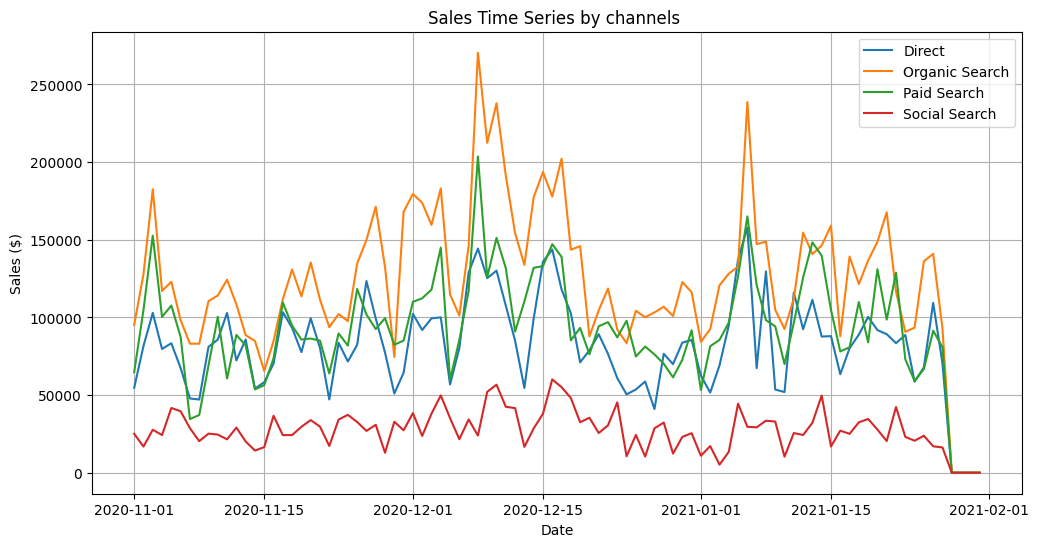

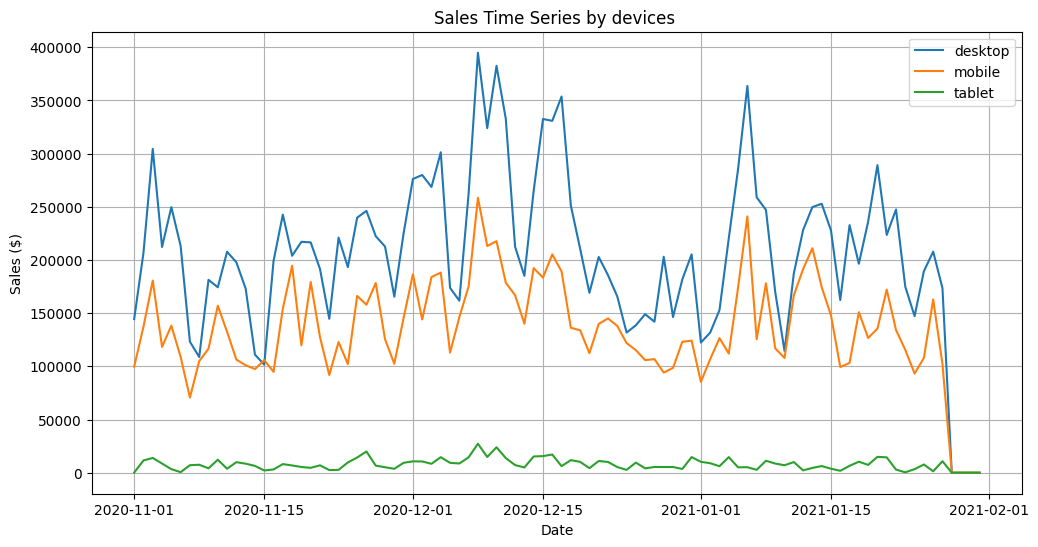

In [ ]:
# Загальна динаміка продажів. Чи спостерігається сезонність продажів?

groupby_date = df.groupby("date")["price"].sum().reset_index(name="sales")

plt.figure(figsize=(12, 6))

plt.plot(groupby_date["date"], groupby_date["sales"], color="green")

plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.title("Sales Time Series ")
plt.legend()
plt.grid(True)
plt.show()

# Динаміка продажів в Америці, Азії та Європі.

continents_dynamic = df[df["continent"].isin(["Americas", "Asia", "Europe"])].groupby(["date", "continent"])["price"].sum().reset_index(name = "sales")
continents_names = continents_dynamic['continent'].unique()
plt.figure(figsize=(12, 6))

for continent in continents_names:
  continent_data = continents_dynamic[continents_dynamic["continent"] == continent]
  plt.plot(continent_data["date"], continent_data["sales"], label = continent)


plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.title("Sales Time Series ")
plt.legend()
plt.grid(True)
plt.show()

# Динаміка продажів у розрізі каналів трафіку.
channels_dynamic = df[df["channel"] != "Undefined"].groupby(["date", "channel"])["price"].sum() .reset_index(name="sales")
channels_names = channels_dynamic["channel"].unique()
print(channels_names)

plt.figure(figsize=(12, 6))

for channel in channels_names:
  channel_data = channels_dynamic[channels_dynamic["channel"] == channel]
  plt.plot(channel_data["date"], channel_data["sales"], label = channel)


plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.title("Sales Time Series by channels ")
plt.legend()
plt.grid(True)
plt.show()

# Динаміка продажів за пристроями.

group_by_devices = df.groupby(by=["date", "device"])["price"].sum().reset_index(name="sales")
devices_name = group_by_devices["device"].unique()

plt.figure(figsize=(12, 6))

for device in devices_name:
  continent_data = group_by_devices[group_by_devices["device"] == device]
  plt.plot(continent_data["date"], continent_data["sales"], label = device)


plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.title("Sales Time Series by devices ")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Кількість сесій у розрізі каналів трафіку та типів девайсів.
filtered_df = df[(df["channel"] != "Undefined") & (df["continent"] != "(not set)")]
pivot_table_sessions = pd.pivot_table(filtered_df, values="ga_session_id", index=["channel", "device"], aggfunc="count").reset_index()
print(f"Sessions count by channels and devices:\n\n {pivot_table_sessions}\n")

# Загальні продажі за категоріями товарів (топ-10 категорій) у різних країнах (топ-5 країн)
top_10_categories_df = df.groupby("category")["price"].sum().reset_index(name="sales").sort_values(by="sales", ascending = False).head(10)
top_10_categories_names = top_10_categories_df["category"].unique()
top_5_countries_names = top_5_countries['country'].unique()
filtered_df_top = df[(df['country'].isin(top_5_countries_names)) & (df["category"].isin(top_10_categories_names))]

top_10_categories_by_countries = pd.pivot_table(filtered_df_top, values="price", index="category", columns="country", aggfunc="sum").reset_index()
print(f"Top-10 categories sales by countries:\n\n {top_10_categories_by_countries}")


# Продажі у розрізі континентів та каналів трафіку
pt_sales = pd.pivot_table(filtered_df, values="price", index=["continent", "channel"], aggfunc="sum").reset_index()
print(f"Sales by continents and devices:\n\n {pt_sales}\n")






Sessions count by channels and devices:

            channel   device  ga_session_id
0           Direct  desktop          47702
1           Direct   mobile          31680
2           Direct   tablet           1808
3   Organic Search  desktop          72426
4   Organic Search   mobile          48915
5   Organic Search   tablet           2782
6      Paid Search  desktop          55055
7      Paid Search   mobile          36960
8      Paid Search   tablet           2137
9    Social Search  desktop          16247
10   Social Search   mobile          10962
11   Social Search   tablet            638

Top-10 categories sales by countries:

 country                          category    Canada    France     India  \
0                           Bar furniture   51724.0   11199.0   57657.0   
1                                    Beds  354772.0  116414.0  358319.5   
2              Bookcases & shelving units  278981.9   73830.0  364507.4   
3                    Cabinets & cupboards  181802.0   5910

## Статистичний аналіз взаємозв’язків.

### Взаємозв'язок кількості сесій та загальних продажів за кожну дату.
Оскільки p-value < 0.05 (2.24477831491671e-51), то взаємозв'язок між кількістю сесій та продажами є статистично значущим. За величиною коофіцієнта кореляції Пірсона (приблизно 0.964) можемо зробити висновок, що є сильний прямий зв'язок.

### Чи корелюють між собою продажі на різних континентах? Візьмемо топ-3 континенти.
   Оскільки візуалізація pairplot показала, що розподіл продажів відхиляється від нормального, для оцінки взаємозв'язку було використано коефіцієнт рангової кореляції Спірмена. Він показав, що є майже однаковий прямий помірно сильний зв'язок між продажами у всіх топ-3 континентів : Америка та Азія (0.67), Америка та Європа (0.63), Європа та Азія (0.61). P-value менше 0.05 та показує, що ті взяємозв'язки є статистично значущими: 1.1001059722381636e-12, 7.009052955139405e-11, 3.2731384105062476e-10 відповідно.
   Така позитивна кореляція показує значну синхронізацію розвитку ринків на цих континентах.

 ### Чи є взаємозв'зок продажів між підписниками та незареєстрованими користувачами?
  Оскільки візуалізація pairplot показала, що розподіл продажів відхиляється від нормального, для оцінки взаємозв'язку було використано коефіцієнт рангової кореляції Спірмена. Він показав слабкий прямий зв'язок продажів між зареєстрованими та незареєстрованими користувачами (0.077). P-value - 0.47, що більше 0.05 та показує, що кореляція не є статистично значущою.

 ### Чи корелююють між собою продажі за різними типами девайсів?
  Оскільки візуалізація pairplot показала, що розподіл продажів відхиляється від нормального, для оцінки взаємозв'язку було використано коефіцієнт рангової кореляції Спірмена. Він показав, що є сильний прямий зв'язок продажів на десктопі та мобільному телефоні (0.77), між продажами на десктопі і планшеті (0.39) та на планшеті і мобільному телефоні - помірна кореляція (0.39) та (0.40) відповідно.
  P-value пдітверджує статистичну значущість результатів:
  1.7614974818574937e-18, 0.00017, 0.0001 відповідно.

  ### Чи корелюють між собою продажі за різними типами трафіку?

  Оскільки візуалізація pairplot показала, що розподіл продажів відхиляється від нормального, для оцінки взаємозв’язку між продажами за каналами трафіку було використано коефіцієнт рангової кореляції Спірмена.

Результати показали наявність переважно сильного прямого зв’язку між окремими каналами:

між Direct та Organic Search спостерігається сильна позитивна кореляція (0.75);
між Direct та Paid Search також виявлено сильний прямий зв’язок (0.69);
найсильніший взаємозв’язок зафіксовано між Organic Search та Paid Search (0.76).

Для каналу Social Search кореляція з іншими каналами є помірною:

з Direct — 0.39;
з Organic Search — 0.39;
з Paid Search — 0.42.

Це свідчить про те, що зміна обсягів продажів у каналах Direct, Organic Search та Paid Search часто відбувається одночасно, тоді як зв’язок із Social Search менш виражений.

Значення p-value підтверджують статистичну значущість усіх отриманих результатів, оскільки для кожної пари каналів вони є меншими за рівень значущості 0.05:

Direct ↔ Organic Search — 5.36 × 10⁻¹⁷;
Direct ↔ Paid Search — 9.51 × 10⁻¹⁴;
Direct ↔ Social Search — 0.00015;
Organic Search ↔ Paid Search — 4.86 × 10⁻¹⁸;
Organic Search ↔ Social Search — 0.00021;
Paid Search ↔ Social Search — 0.00005.

### Чи існує кореляція між продажами за топ-5 категоріями товарів?
Оскільки візуалізація pairplot показала відхилення розподілу продажів від нормального, для оцінки взаємозв’язку між продажами різних категорій товарів було використано коефіцієнт рангової кореляції Спірмена.

Результати показали, що між усіма досліджуваними категоріями існує позитивний статистично значущий зв’язок помірної або помірно сильної сили.

Найвищі значення кореляції спостерігаються:

між Chairs та Bookcases & shelving units — 0.64;
між Sofas & armchairs та Cabinets & cupboards — 0.63;
між Sofas & armchairs та Bookcases & shelving units — 0.63.

Також виявлено помітний позитивний зв’язок:

між Sofas & armchairs та Chairs — 0.58;
між Beds та Bookcases & shelving units — 0.54;
між Chairs та Beds — 0.54;
між Chairs та Cabinets & cupboards — 0.53;
між Bookcases & shelving units та Cabinets & cupboards — 0.53;
між Sofas & armchairs та Beds — 0.52.

Найнижча, хоча все ще помірна позитивна кореляція, спостерігається між:

Beds та Cabinets & cupboards — 0.44.

Це може свідчити про те, що зростання продажів в одних меблевих категоріях часто супроводжується зростанням продажів в інших категоріях — ймовірно через спільний попит, комплексні покупки або сезонні фактори.

Значення p-value підтверджують статистичну значущість усіх результатів, оскільки для кожної пари категорій вони є значно меншими за рівень значущості 0.05:

від 2.46 × 10⁻⁹ до 1.76 × 10⁻⁵.

Test statistic and p-value: PearsonRResult(statistic=np.float64(0.7910809164540891), pvalue=np.float64(6.483532312080735e-21))
Pearson Correlation: 0.7910809164540887
          date     sales
0   2020-11-01  244292.5
1   2020-11-02  355506.8
2   2020-11-03  498979.6
3   2020-11-04  339187.1
4   2020-11-05  391276.6
..         ...       ...
87  2021-01-27  286340.7
88  2021-01-28       0.0
89  2021-01-29       0.0
90  2021-01-30       0.0
91  2021-01-31       0.0

[92 rows x 2 columns]


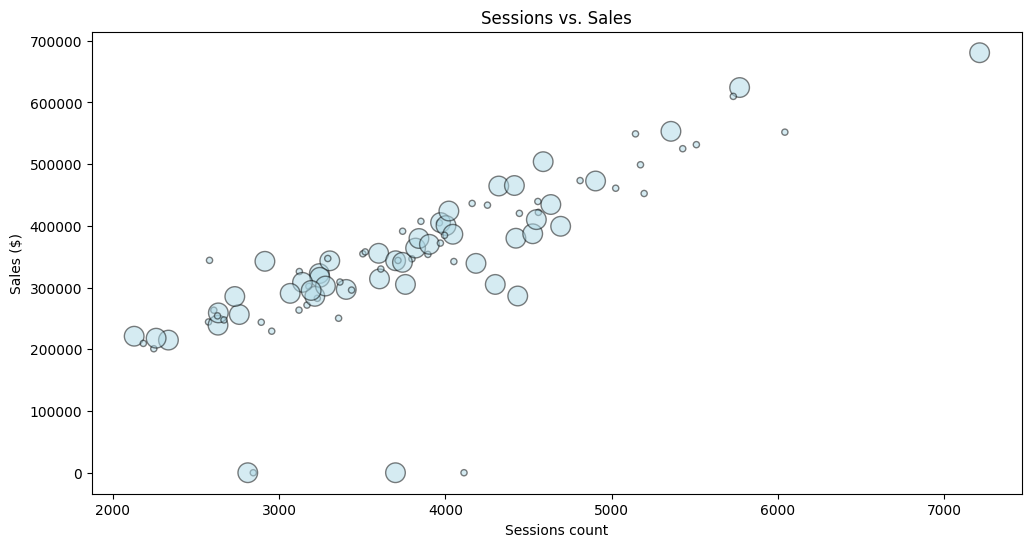

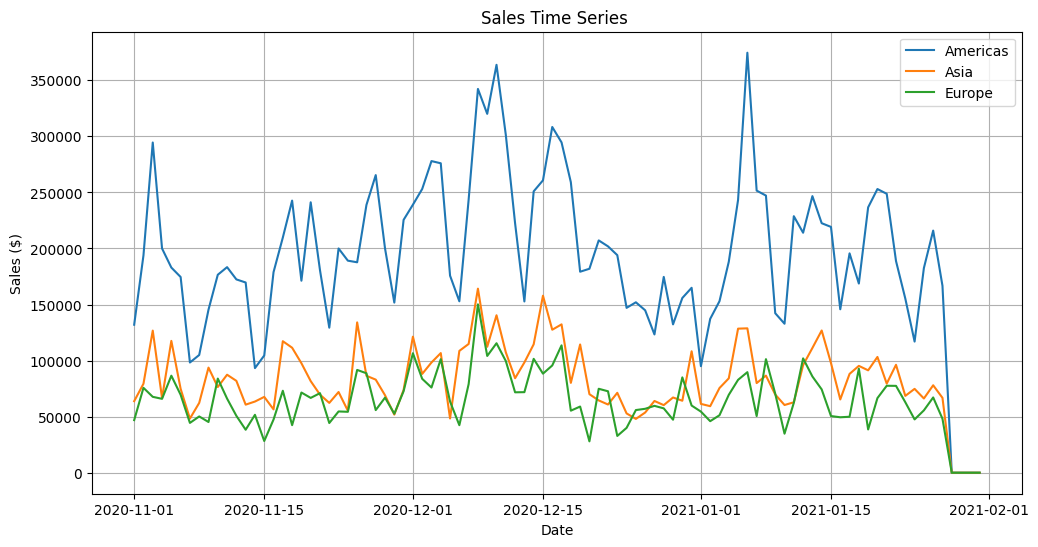

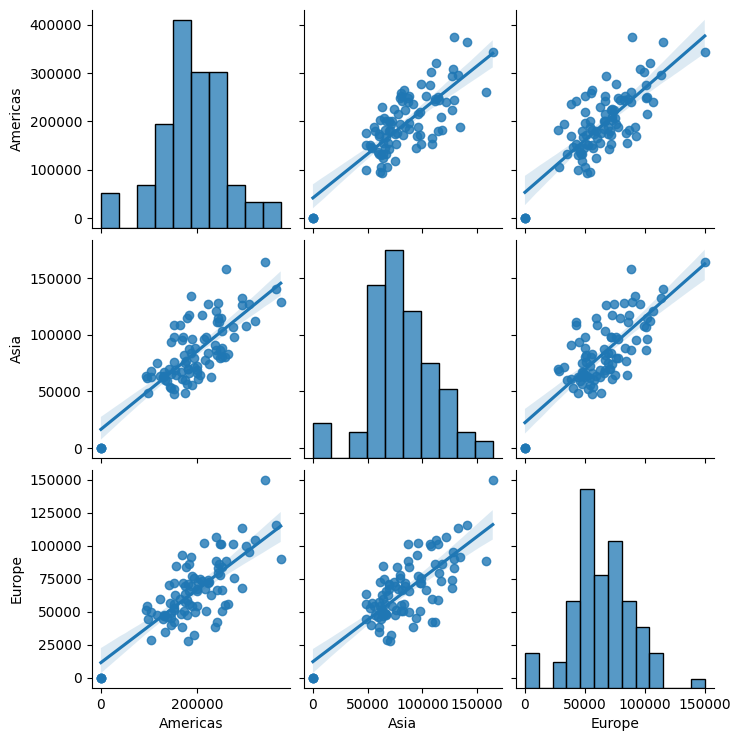

Test statistic and p-value Americas and Asia: SignificanceResult(statistic=np.float64(0.7099016615801969), pvalue=np.float64(2.3233796296203977e-15))
Test statistic and p-value Americas and Europe: SignificanceResult(statistic=np.float64(0.6725700545639509), pvalue=np.float64(2.1035588726455927e-13))
Test statistic and p-value Europe and Asia: SignificanceResult(statistic=np.float64(0.6571102685039614), pvalue=np.float64(1.1290947217450973e-12))
Spearman Correlation Americas and Asia: 0.7099016615801969
Spearman Correlation Americas and Europe: 0.6725700545639509
Spearman Correlation Europe and Asia: 0.6571102685039614
          date  subscribed_sales  unsubscribed_sales
0   2020-11-01           17288.0              4259.0
1   2020-11-02           35576.8              9380.0
2   2020-11-03           21391.5              7759.0
3   2020-11-04           17107.2              3875.0
4   2020-11-05           24158.6              1176.0
..         ...               ...                 ...
83

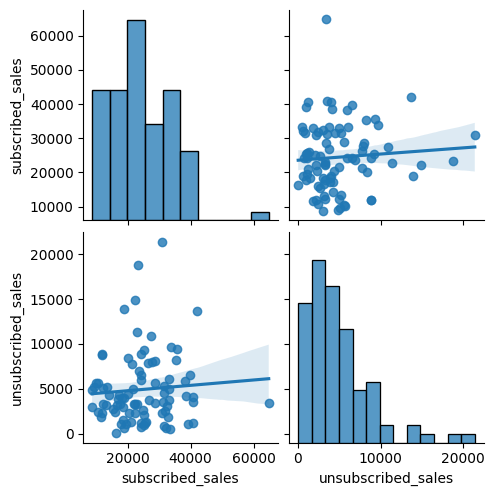

Test statistic and p-value A: SignificanceResult(statistic=np.float64(0.07738367792610334), pvalue=np.float64(0.4736089665290931))
Spearman Correlation : 0.07738367792610334
device       desktop    mobile   tablet
date                                   
2020-11-01  144445.0   99698.5    149.0
2020-11-02  206727.3  137269.5  11510.0
2020-11-03  304473.8  180602.8  13903.0
2020-11-04  212227.7  118324.4   8635.0
2020-11-05  249682.0  138256.0   3338.6
...              ...       ...      ...
2021-01-27  173453.5  102042.2  10845.0
2021-01-28       0.0       0.0      0.0
2021-01-29       0.0       0.0      0.0
2021-01-30       0.0       0.0      0.0
2021-01-31       0.0       0.0      0.0

[92 rows x 3 columns]


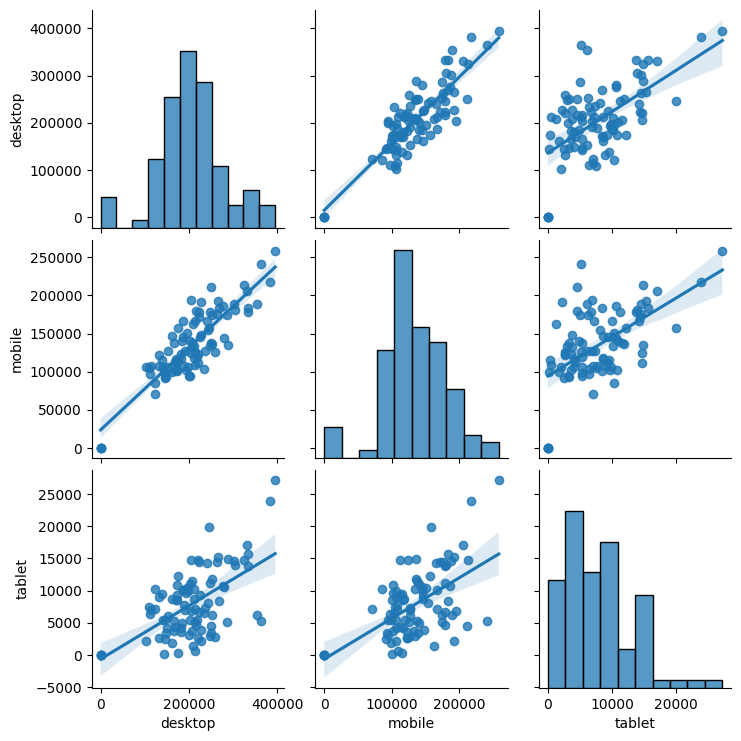

Test statistic and p-value desktop and mobile: SignificanceResult(statistic=np.float64(0.7988840593113229), pvalue=np.float64(1.4084027267169306e-21))
Test statistic and p-value desktop and tablet: SignificanceResult(statistic=np.float64(0.46636173418814064), pvalue=np.float64(2.7941441242388197e-06))
Test statistic and p-value tablet and mobile: SignificanceResult(statistic=np.float64(0.47612625284060167), pvalue=np.float64(1.6098778065015907e-06))
Spearman Correlation desktop and mobile : 0.7988840593113229
Spearman Correlation desktop and tablet : 0.46636173418814064
Spearman Correlation mobile and tablet : 0.47612625284060167


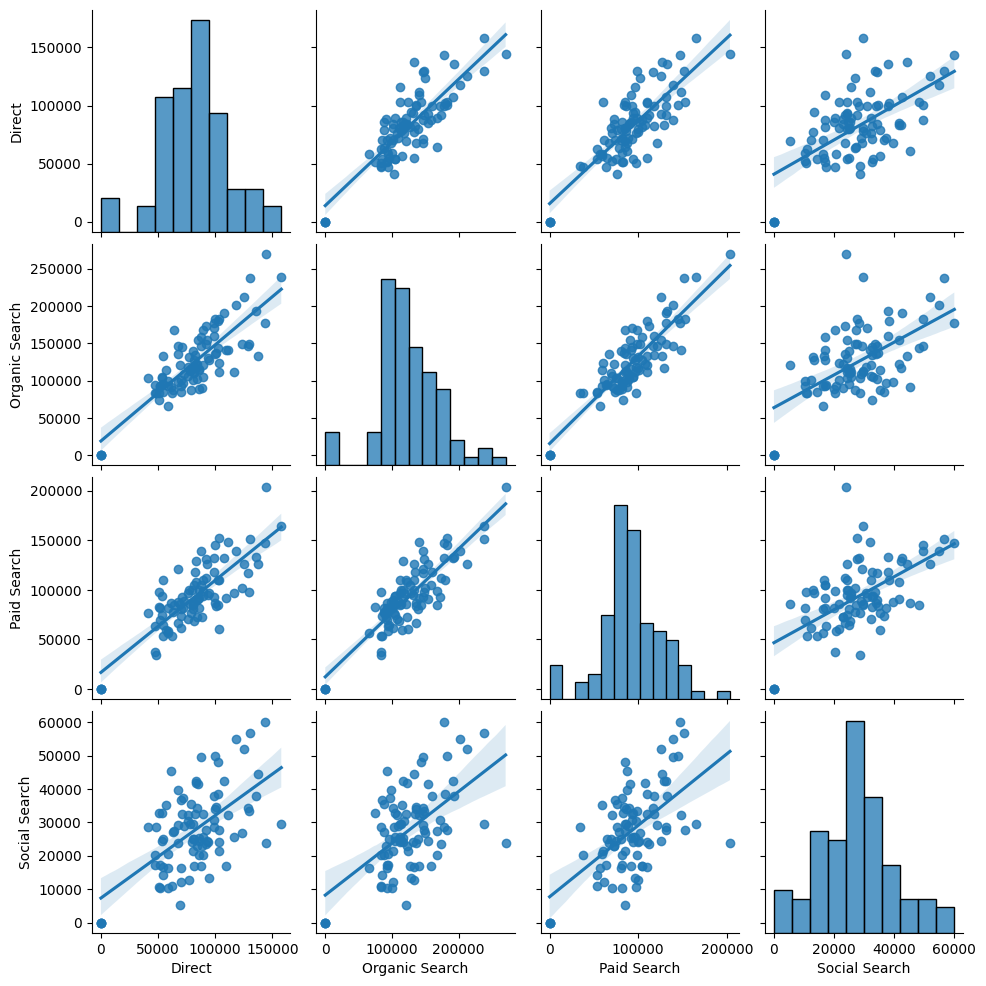


Direct ↔ Organic Search
Spearman correlation: 0.780
p-value: 5.405253983075643e-20
Result is statistically important

Direct ↔ Paid Search
Spearman correlation: 0.729
p-value: 1.65402161751709e-16
Result is statistically important

Direct ↔ Social Search
Spearman correlation: 0.469
p-value: 2.365556386712662e-06
Result is statistically important

Organic Search ↔ Paid Search
Spearman correlation: 0.793
p-value: 4.16183654939949e-21
Result is statistically important

Organic Search ↔ Social Search
Spearman correlation: 0.462
p-value: 3.6452140656893687e-06
Result is statistically important

Paid Search ↔ Social Search
Spearman correlation: 0.493
p-value: 6.0588880791877e-07
Result is statistically important


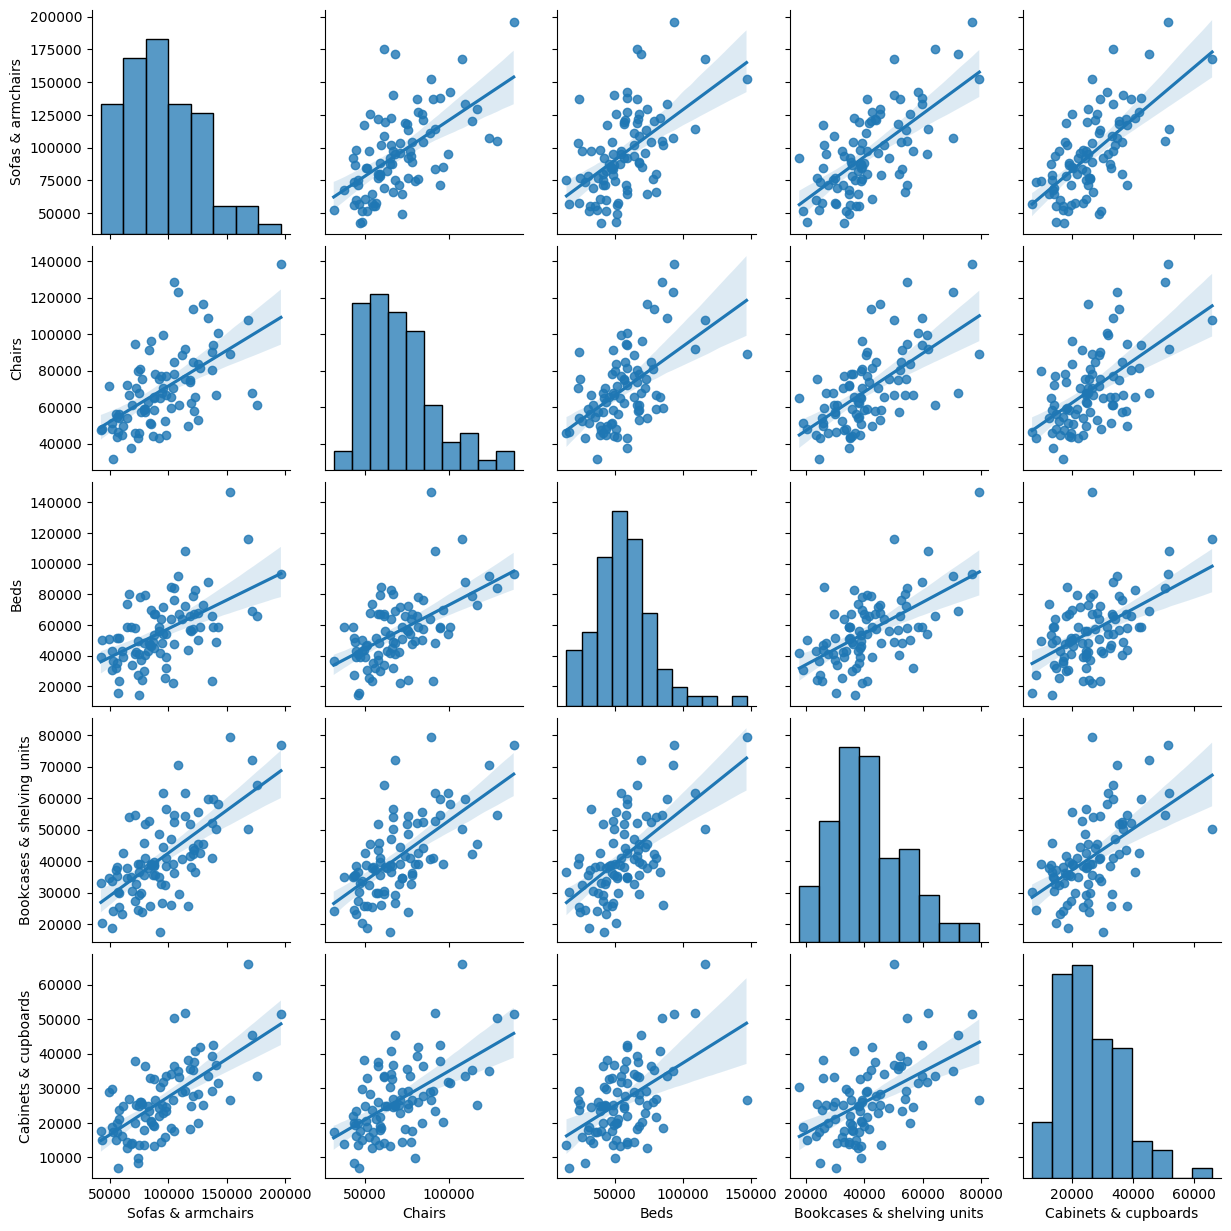


Sofas & armchairs ↔ Chairs
Spearman correlation: nan
p-value: nan
There is no statistically important result

Sofas & armchairs ↔ Beds
Spearman correlation: nan
p-value: nan
There is no statistically important result

Sofas & armchairs ↔ Bookcases & shelving units
Spearman correlation: nan
p-value: nan
There is no statistically important result

Sofas & armchairs ↔ Cabinets & cupboards
Spearman correlation: nan
p-value: nan
There is no statistically important result

Chairs ↔ Beds
Spearman correlation: nan
p-value: nan
There is no statistically important result

Chairs ↔ Bookcases & shelving units
Spearman correlation: nan
p-value: nan
There is no statistically important result

Chairs ↔ Cabinets & cupboards
Spearman correlation: nan
p-value: nan
There is no statistically important result

Beds ↔ Bookcases & shelving units
Spearman correlation: nan
p-value: nan
There is no statistically important result

Beds ↔ Cabinets & cupboards
Spearman correlation: nan
p-value: nan
There is no st

In [ ]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from itertools import combinations

# Знайдемо кількість сесій та загальні продажі за кожну дату. Створимо візуалізацію, щоб побачити взаємозв’язок між цими метриками. Чи корелюють ці показники?
sessions_by_date = df.groupby("date")["ga_session_id"].count().reset_index(name="sessions_cnt")
sales_by_date =  df.groupby("date")["price"].sum().reset_index(name="sales")

print(f"Test statistic and p-value: {pearsonr(sessions_by_date["sessions_cnt"], sales_by_date['sales'])}")
pearson_corr = sessions_by_date["sessions_cnt"].corr(sales_by_date["sales"])
print(f"Pearson Correlation: {pearson_corr}")

plt.style.use("default")
plt.figure(figsize=(12, 6))
plt.scatter(sessions_by_date["sessions_cnt"], sales_by_date["sales"],  alpha=0.5, sizes=(20,200), color="lightblue", edgecolors="black")
plt.title("Sessions vs. Sales")
plt.xlabel("Sessions count")
plt.ylabel("Sales ($)")
print(sales_by_date)

# Чи корелюють між собою продажі на різних континентах? Візьмемо топ-3 континенти.

plt.figure(figsize=(12, 6))

for continent in continents_names:
  continent_data = continents_dynamic[continents_dynamic["continent"] == continent]
  plt.plot(continent_data["date"], continent_data["sales"], label = continent)


plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.title("Sales Time Series ")
plt.legend()
plt.grid(True)
plt.show()

wide_table = pd.pivot_table(data=continents_dynamic, values="sales", index="date", columns="continent").reset_index()
sns.pairplot(wide_table[['Americas', "Asia", "Europe"]], kind="reg")
plt.show()

print( f"Test statistic and p-value Americas and Asia: {spearmanr(wide_table["Americas"], wide_table['Asia'])}"
)
print( f"Test statistic and p-value Americas and Europe: {spearmanr(wide_table["Americas"], wide_table['Europe'])}"
)
print( f"Test statistic and p-value Europe and Asia: {spearmanr(wide_table["Europe"], wide_table['Asia'])}"
)

spearman_corr_Americas_Asia = wide_table['Americas'].corr(wide_table['Asia'], method="spearman")
spearman_corr_Americas_Europe = wide_table['Americas'].corr(wide_table['Europe'], method="spearman")
spearman_corr_Europe_Asia = wide_table['Europe'].corr(wide_table['Asia'], method="spearman")

print(f"Spearman Correlation Americas and Asia: {spearman_corr_Americas_Asia}")
print(f"Spearman Correlation Americas and Europe: {spearman_corr_Americas_Europe}")
print(f"Spearman Correlation Europe and Asia: {spearman_corr_Europe_Asia}")


# Чи є взаємозв'зок продажів між підписниками та незареєстрованими користувачами?

dynamic_subscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 0].groupby("date")["price"].sum().reset_index(name="subscribed_sales")
dynamic_unsubscribed = df[df["account_id"].notnull() & df["is_unsubscribed"] == 1].groupby("date")["price"].sum().reset_index(name="unsubscribed_sales")
merge_table = pd.merge(dynamic_subscribed, dynamic_unsubscribed, on="date")
print(merge_table)
sns.pairplot(merge_table[["subscribed_sales", "unsubscribed_sales"]], kind="reg")
plt.show()

print( f"Test statistic and p-value A: {spearmanr(merge_table['subscribed_sales'], merge_table['unsubscribed_sales'])}"
)
spearman_corr = merge_table['subscribed_sales'].corr(merge_table['unsubscribed_sales'], method="spearman")
print(f"Spearman Correlation : {spearman_corr}")

# Чи корелююють між собою продажі за різними типами девайсів?

devices_table = pd.pivot_table(data=df, index="date", columns="device", values="price", aggfunc="sum")
print(devices_table)
sns.pairplot(devices_table[["desktop", "mobile", "tablet"]], kind="reg")
plt.show()

print( f"Test statistic and p-value desktop and mobile: {spearmanr(devices_table["desktop"], devices_table['mobile'])}")
print( f"Test statistic and p-value desktop and tablet: {spearmanr(devices_table["desktop"], devices_table['tablet'])}")
print( f"Test statistic and p-value tablet and mobile: {spearmanr(devices_table["tablet"], devices_table['mobile'])}")

spearman_corr_desktop_mobile = devices_table["desktop"].corr(devices_table["mobile"], method="spearman")
spearman_corr_desktop_tablet = devices_table["desktop"].corr(devices_table["tablet"], method="spearman")
spearman_corr_tablet_mobile = devices_table["tablet"].corr(devices_table["mobile"], method="spearman")
print(f"Spearman Correlation desktop and mobile : {spearman_corr_desktop_mobile}")
print(f"Spearman Correlation desktop and tablet : {spearman_corr_desktop_tablet}")
print(f"Spearman Correlation mobile and tablet : {spearman_corr_tablet_mobile}")

# Аналіз кореляції продажів за каналами трафіку
filtered_df_channels = df[df['channel'] != "Undefined"]
channels_table = pd.pivot_table(data=filtered_df_channels, index="date", columns="channel", values="price", aggfunc="sum")
selected_channels = ['Direct', 'Organic Search', 'Paid Search', 'Social Search']
sns.pairplot(channels_table[selected_channels], kind="reg")
plt.show()

for ch1, ch2 in combinations(selected_channels, 2):

    corr, p_value = spearmanr(channels_table[ch1], channels_table[ch2])
    print(f'\n{ch1} ↔ {ch2}')
    print(f'Spearman correlation: {corr:.3f}')
    print(f'p-value: {p_value:}')
    if p_value < 0.05:
      print("Result is statistically important")
    else:
      print("There is no statistically important result")

# Аналіз кореляції продажів за топ-5 категоріями товарів

top_5_categories = df.groupby("category")["price"].sum().reset_index(name="sales").sort_values(by="sales", ascending= False).head(5)
grouped_by_date_category =  df.groupby(["date", "category"])["price"].sum().reset_index(name="sales")
top_categories_names = top_5_categories["category"].unique()
categories_table = pd.pivot_table(data=grouped_by_date_category, index="date", columns="category", values='sales')
sns.pairplot(categories_table[top_categories_names], kind="reg")
plt.show()

for cat1, cat2 in combinations(top_categories_names, 2):

    corr, p_value = spearmanr(categories_table[cat1], categories_table[cat2])
    print(f'\n{cat1} ↔ {cat2}')
    print(f'Spearman correlation: {corr:.3f}')
    print(f'p-value: {p_value:}')
    if p_value < 0.05:
      print("Result is statistically important")
    else:
      print("There is no statistically important result")



## Статистичний аналіз відмінностей між групами.

- Виявлено статистично значущу різницю між групами зареєстрованих та незареєстрованих користвачів (p < 0.05). Величина ефекту є великою (RBC = 0.968), що свідчить про суттєві відмінності в продажах між зареєстрованими та незареєстрованими користувачами.

 - У результаті тестування частки сесій з органічного каналу в Америці та Європі не виявлено статистично значущої різниці p-value = 0.46.

- У результаті порівняння кількості сесій користувачів з різних каналів трафіку за допомогою тесту Крускала-Уолліса виявлена статистично значима різниця p-value = 8.740916570888748e-53




         date  subscribed_sales  unsubscribed_sales
0  2020-11-01           17288.0              4259.0
1  2020-11-02           35576.8              9380.0
2  2020-11-03           21391.5              7759.0
3  2020-11-04           17107.2              3875.0
4  2020-11-05           24158.6              1176.0
5  2020-11-06           10624.6              2430.0
6  2020-11-07           13445.0              5241.0
7  2020-11-08           18228.0              3940.0
8  2020-11-09           18971.0             13913.0
9  2020-11-10           40717.0              4045.0
       subscribed_sales  unsubscribed_sales
count         88.000000           88.000000
mean       24440.873864         4905.927273
std         9725.707911         3953.952472
min         8778.000000           60.000000
25%        17854.000000         2301.750000
50%        23863.800000         3823.000000
75%        31584.750000         6190.000000
max        64731.100000        21380.000000


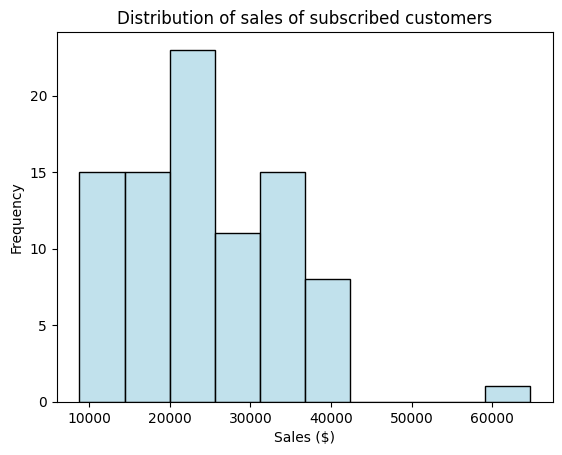

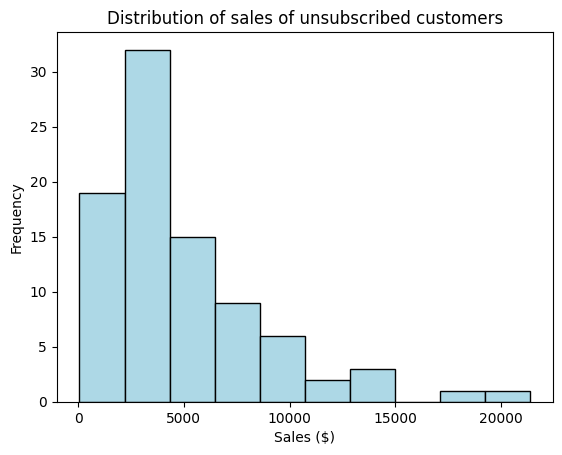

Shapiro-Wilk for subscibed customers sales data p-value: 0.0018539954208119539
Shapiro-Wilk for unsubscibed customers sales data p-value: 4.0876403097868696e-08
U-statistic: 7619.0, p-value: 1.4787066504202697e-28
Rank-Biserial Correlation = 0.968
Z-statistic: 0.28951412926103953
P-value: 0.7721879690501752
No statistically significant difference between versions A and B.
channel     Direct  Organic Search  Paid Search  Social Search
date                                                          
2020-11-01     608             920          706            214
2020-11-02     810            1242          970            315
2020-11-03    1216            1871         1367            392
2020-11-04     935            1425         1145            368
2020-11-05     845            1293          917            346
...            ...             ...          ...            ...
2021-01-27     984            1561         1192            359
2021-01-28     997            1379         1107           

In [ ]:
from scipy.stats import shapiro, mannwhitneyu, kruskal
import statsmodels.api as sm
### Статистичний аналіз продажів за кожну дату зареєстрованих та незареєстрованих користувачів.
print(merge_table.head(10))
print(merge_table.describe())

# Графік розподілу значень для зареєстрованих та незареєстрованих користувачів
sns.histplot(data=merge_table,  x="subscribed_sales", bins= 10, color="lightblue", edgecolor="black")
plt.title("Distribution of sales of subscribed customers")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.show()

plt.hist(merge_table['unsubscribed_sales'], bins= 10, color="lightblue", edgecolor="black" )
plt.title("Distribution of sales of unsubscribed customers")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.show()

# Оскільки вибірка невелика для визначення нормальності розподілу використовуємо тест Шапіро-Уілка. Якщо p-значення менше 0.05 - розподіл ненормальний.
_, p_value_shapiro_subscribed = shapiro(merge_table['subscribed_sales'])
_, p_value_shapiro_unsubscribed = shapiro(merge_table['unsubscribed_sales'])

print(f"Shapiro-Wilk for subscibed customers sales data p-value: {p_value_shapiro_subscribed}")
print(f"Shapiro-Wilk for unsubscibed customers sales data p-value: {p_value_shapiro_unsubscribed}")

# Для порівняння вибірок з ненормальним розподілом використовуємо Манна-Уїтні. Якщо p-значення менше 0.05 - є стистично значуща різниця між покупками двох груп.

u_stat, p_value = mannwhitneyu(merge_table['subscribed_sales'], merge_table['unsubscribed_sales'])
print(f"U-statistic: {u_stat}, p-value: {p_value}")

# Розрахунок Rank-Biserial Correlation
rbc = (2 * u_stat) / (len(merge_table['subscribed_sales']) * len(merge_table['unsubscribed_sales'])) -1
print(f"Rank-Biserial Correlation = {rbc:.3f}")


### Чи відрізняється статистично доля сесій з органічним трафіком у Європі та Америці?
filter_df = df[(df['continent'].isin(["Europe", "Americas"])) & (df['channel'] == "Organic Search")]
filter_df_all = df[df['continent'].isin(["Europe", "Americas"])]
grouped_by_continent_count = filter_df_all.groupby("continent")["ga_session_id"].count()
organic_count = filter_df.groupby("continent")["ga_session_id"].count()

z_stat, p_value = sm.stats.proportions_ztest([organic_count["Europe"], organic_count["Americas"]], [grouped_by_continent_count["Europe"], grouped_by_continent_count["Americas"]])
print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")
if p_value < 0.05:
    print("There is a statistically significant difference between versions A and B.")
else:
    print("No statistically significant difference between versions A and B.")

# print(f"Sessions all by continents: {grouped_by_continent_count}")
# print(f"Sessions by organic channel and continents:\n\n {organic_count}")

### Аналіз  кількості сесій за різними каналами трафіку. Чи є статистично значущі відмінності між групами?
filter_channel = df[df['channel'] != "Undefined"]
sessions_pt = pd.pivot_table(data=filter_channel, index="date", columns="channel", values="ga_session_id", aggfunc="count")
print(sessions_pt)
stat, p_value = kruskal(sessions_pt['Direct'], sessions_pt['Organic Search'], sessions_pt['Paid Search'], sessions_pt['Social Search'])

print(f"Kruskal-Wallis statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a significant difference in sessions from different pages channels.")
else:
    print("There is no significant difference in sessions from different pages channels.")




Посилання на дешборд:
https://public.tableau.com/shared/SDNWRWYPP?:display_count=n&:origin=viz_share_link

## Загальний висновок.

### Компанія має сильну залежність від:

- органічного пошуку;
- американського ринку;
- сезонних піків попиту.

При цьому:

- більшість продажів здійснюється без авторизації;
- email-комунікація виглядає стабільною:  
71.5% зареєстрованих користувачів підтвердили email.16.1% відписались від розсилки.

Це хороший показник підтвердження акаунтів → процес реєстрації виглядає якісним. Можна додатково дослідити частоту комунікацій та якість email-кампаній;
- Продажі майже порівну розподілені між desktop та mobile → важлива кросплатформна оптимізація.

### Основні напрями розвитку:

-  Продовжувати інвестувати в SEO, оскільки Organic Search забезпечує найбільшу виручку.
- Проаналізувати ефективність Paid Search, адже канал генерує значний обсяг продажів і має потенціал для масштабування.
- Дослідити причини низької частки Social Search та оцінити доцільність подальших інвестицій у цей канал.
- Окремо проаналізувати грудневий період, оскільки саме тоді спостерігаються максимальні продажі в усіх каналах.
- збільшувати частку зареєстрованих користувачів;

